interactive(children=(FloatSlider(value=0.0, description='K', max=3.0, step=0.2), Output()), _dom_classes=('wi…

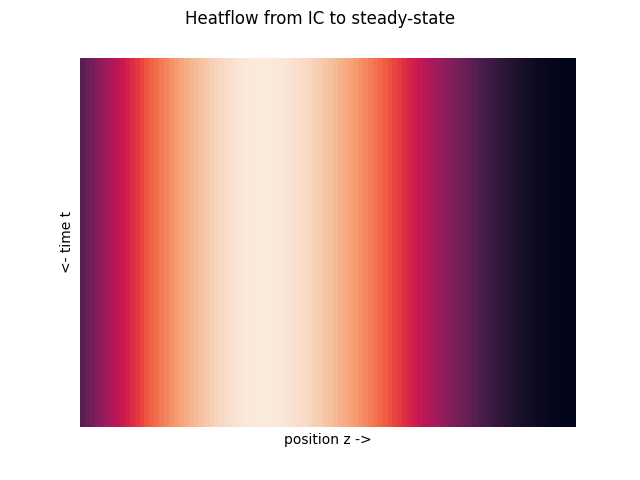

In [5]:
from ipywidgets import FloatSlider, IntSlider, interact
%matplotlib widget

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import sin, exp, pi

L = 1

z = np.linspace(0,  L, 100)
t = np.linspace(0, 0.3, 100)

Z, T = np.meshgrid(z,t)

def soln(K):
    return(
     3*exp(-K*(  pi/2/L)**2*T)*sin(  pi*Z/2/L)
    +5*exp(-K*(3*pi/2/L)**2*T)*sin(3*pi*Z/2/L)
)

fig, ax = plt.subplots(1,1)
plt.suptitle('Heatflow from IC to steady-state')

@interact(
    K = FloatSlider(min=0, max=3, step=0.2)
)
def plot_heat(K):
    ax.clear()
    sns.heatmap(soln(K), ax=ax, xticklabels=False, yticklabels=False, cbar=False)
    ax.set_xlabel('position z ->')
    ax.set_ylabel('<- time t')


interactive(children=(FloatSlider(value=1.0, description='c', max=3.0, step=0.2), FloatSlider(value=0.0, descr…

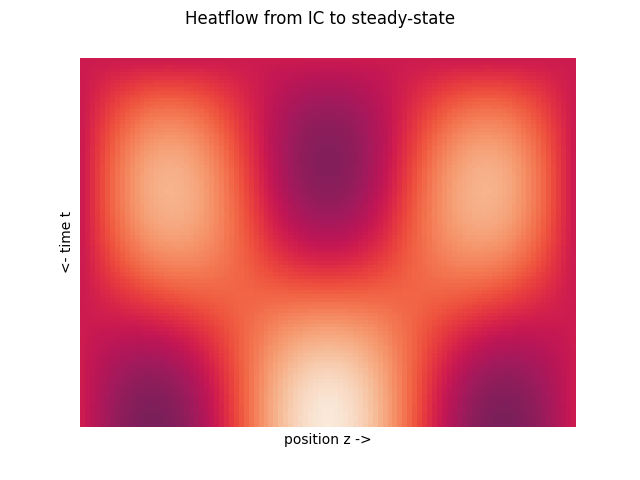

In [17]:
from ipywidgets import FloatSlider, IntSlider, interact
%matplotlib widget

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import sin, cos, pi

L = 1

x = np.linspace(0, L, 100)
y = np.linspace(0, L, 100)

X, Y = np.meshgrid(z,t)

def soln(c, t):
    return(
         3*sin(  pi*X/L)*sin(2*pi*Y/L)*cos((5 )**(1/2)*c*t*pi/L)
        +4*sin(3*pi*X/L)*sin(5*pi*Y/L)*cos((34)**(1/2)*c*t*pi/L)
)

fig, ax = plt.subplots(1,1)
plt.suptitle('Heatflow from IC to steady-state')

@interact(
    c = FloatSlider(value=1, min=0, max=3, step=0.2),
    t = FloatSlider(value=0, min=0, max=3, step=0.02)
)
def plot_heat(c, t):
    ax.clear()
    sns.heatmap(soln(c, t), ax=ax, 
                xticklabels=False, yticklabels=False, 
                cbar=False, vmin=-7, vmax=7)
    ax.set_xlabel('position z ->')
    ax.set_ylabel('<- time t')

interactive(children=(IntSlider(value=10, description='N', max=500, min=1), IntSlider(value=1, description='A'…

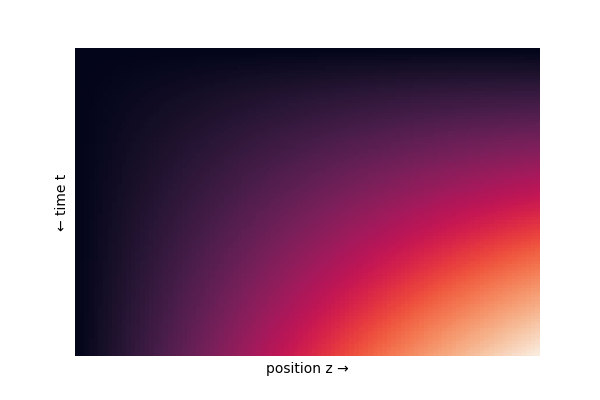

In [8]:
# Chatgpt version

from functools import lru_cache
import numpy as np
from numpy import pi, sin, exp

L = 1
K = 1
A = 1

z = np.linspace(0,  L, 100)
t = np.linspace(0, 1, 100)
Z, T = np.meshgrid(z, t)

maxN = 500               # max slider value
n = np.arange(1, maxN+1) # [1,2,...,100]

lambda_n = (n*pi/L)**2
SIN = np.sin((n[:,None] * pi / L) * z[None,:])      # (N, Z)
EXP = np.exp(-K * lambda_n[:,None] * t[None,:])      # (N, T)

# shape (N, T, Z)
BASIS = EXP[:,:,None] * SIN[:,None,:]


def soln(N, A):
    """
    Compute u(z,t) using first N terms.
    """
    n = np.arange(1, N+1)

    # coefficients: ((-1)^n A^2 L^2)/(K (nπ)^3)
    c_n = ((-1)**n) * (A*A * L*L) / (K * (n*pi)**3)     # (N,)

    # (exp - 1) * sin
    exp_minus_1 = (EXP[:N] - 1)[:,:,None] * SIN[:N][:,None,:]   # (N,T,Z)

    # Sum over modes using tensordot
    u_modes = np.tensordot(c_n, exp_minus_1, axes=(0,0))        # (T,Z)

    # Add the linear term z*A*t/L
    return u_modes + (Z * A * T) / L

fig, ax = plt.subplots(figsize=(6,4))
cbar = None

@interact(
    N   = IntSlider(min=1, max=maxN, value=10),
    A   = 1
)
def plot_heat(N, A):
    global cbar
    ax.clear()

    hm = sns.heatmap(soln(N, A),
                     ax=ax, cbar=False,
                     xticklabels=False, yticklabels=False)

    ax.set_xlabel("position z →")
    ax.set_ylabel("← time t")
    fig.canvas.draw_idle()


In [3]:
np.arange(1,1)

array([], dtype=int64)